## UBC Ovarian Cancer Subtype Classification and Outlier Detection (UBC-OCEAN) - JPEG Dataset Pipeline

Props to https://www.kaggle.com/code/gunesevitan/ubc-ocean-jpeg-dataset-pipeline

## 1. Setup

In [2]:
import os
os.environ['OPENCV_IO_MAX_IMAGE_PIXELS'] = str(pow(2, 40))

from pathlib import Path
from tqdm.notebook import tqdm
import concurrent.futures
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import json
import zipfile
import skimage
from io import TextIOWrapper

In [3]:
competition_dataset_directory = Path('input')

## 2. Introduction

There are 538 images in training set. 513 of them are whole slide images (WSIs) and 25 of them are tissue microarrays (TMAs). All of them take 775 GBs of disk space which could be intimidating and not easily approachable for some audience. It's not even possible to download such large data from some countries due to slow internet connection. That problem is solved to some extend in this notebook.

In [4]:
import PIL
PIL.Image.MAX_IMAGE_PIXELS = 20971520000

def read_train_csv(zip_file_path, csv_file_name):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        with zip_ref.open(csv_file_name) as file:
        # Wrap the file with TextIOWrapper to make it compatible with pandas.read_csv
            csv_file = TextIOWrapper(file, encoding='utf-8')
            return pd.read_csv(csv_file)


def load_train_image(image_id, updated_images_description):
    try:
        if is_updated_image(updated_images_description, image_id):
            image_file_name = f'{image_id}.png'
            zip_file_path = competition_dataset_directory / 'train_images' / f'{image_file_name}.zip'
        else:
            image_file_name = f'train_images/{image_id}.png'
            zip_file_path = competition_dataset_directory / 'UBC-OCEAN.zip'
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            with zip_ref.open(image_file_name) as file:
                # Return the image as a numpy array
                return skimage.io.imread(file).astype(np.uint8)
    except KeyError:
        print(f'WARNING: Could not find {image_file_name} in zip file')
        return np.zeros((100, 100, 3), dtype=np.uint8)
        

def load_train_thumbnail(image_id, updated_images_description):
    try:
        if is_updated_image(updated_images_description, image_id):
            thumbnail_file_name = f'{image_id}_thumbnail.png'
            zip_file_path = competition_dataset_directory / 'train_thumbnails' / f'{thumbnail_file_name}.zip'
        else:
            thumbnail_file_name = f'train_thumbnails/{image_id}_thumbnail.png'
            zip_file_path = competition_dataset_directory / 'UBC-OCEAN.zip'
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            with zip_ref.open(thumbnail_file_name) as file:
                # Return the image as a numpy array
                return skimage.io.imread(file).astype(np.uint8)
    except KeyError:
        print(f'WARNING: Could not find {thumbnail_file_name} in zip file')
        return np.zeros((100, 100, 3), dtype=np.uint8)
    

def is_updated_image(updated_images_description, image_id):
    return str(image_id) in updated_images_description
        

In [5]:
def load_updated_images_description():
    with open('updated_image_ids.json') as json_file:
        return json.load(json_file)

updated_images_description = load_updated_images_description()
df_train = pd.read_csv(competition_dataset_directory / 'train.csv')
df_test = pd.read_csv(competition_dataset_directory / 'test.csv')

df_train

,image_id,label,image_width,image_height,is_tma
0,4,HGSC,23785,20008,False
1,66,LGSC,48871,48195,False
2,91,HGSC,3388,3388,True
3,281,LGSC,42309,15545,False
4,286,EC,37204,30020,False
...,...,...,...,...,...
533,65022,LGSC,53355,46675,False
534,65094,MC,55042,45080,False
535,65300,HGSC,75860,27503,False
536,65371,HGSC,42551,41800,False


## 3. JPEG Compression

JPEG compression is a process that aims to reduce file size by selectively eliminating less noticeable image details. The algorithm is created to preserve the most important details, particularly when using higher quality settings.

If you choose higher quality settings, you'll only see a drop in quality when you look at the image really closely. But if you use lower quality settings, you'll notice problems with the image more easily. That's the important trade-off between memory and image quality. For large images like the ones here, you can opt towards memory a bit more safely.

In [6]:
def visualize_image(image, title, path=None):

    """
    Visualize the given image

    Parameters
    ----------
    image: numpy.ndarray of shape (height, width, channel)
        Image array
        
    title: str
        Title of the plot

    path: str or None
        Path of the output file or None (if path is None, plot is displayed with selected backend)
    """

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=15, pad=10)
    ax.tick_params(axis='y', labelsize=15, pad=10)
    ax.set_title(title, size=15, pad=12.5, loc='center', wrap=True)

    if path is None:
        plt.show()
    else:
        plt.savefig(path)
        plt.close(fig)


First row of the training set is selected to show effects of JPEG compression. 

In [6]:
first_row = df_train.loc[0]
new_image_id = 34690
# image = load_train_image(first_row['image_id'], updated_images_description)
image = load_train_image(new_image_id, updated_images_description)
raw_image_size = len(image.tobytes()) / (1 << 20)

Raw image size is **576.34** MBs in lossless PNG format.

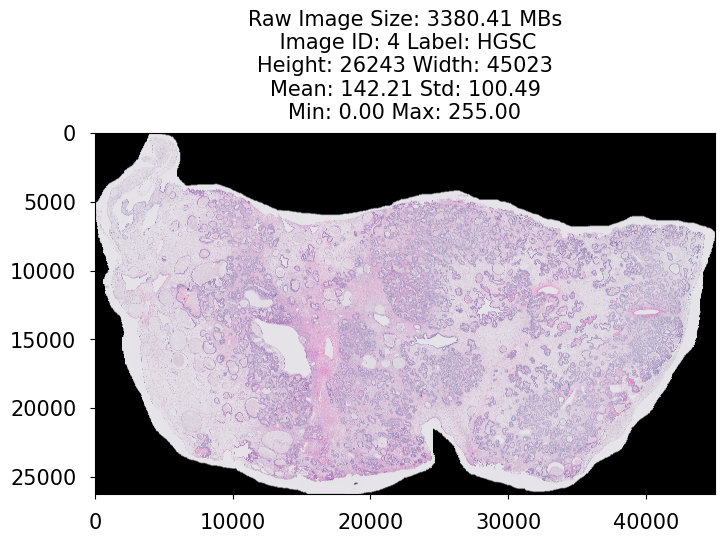

In [7]:
visualize_image(
    image=image,
    title=f'Raw Image Size: {raw_image_size:.2f} MBs\n Image ID: {first_row["image_id"]} Label: {first_row["label"]}\nHeight: {image.shape[0]} Width: {image.shape[1]}\nMean: {np.mean(image):.2f} Std: {np.std(image):.2f}\nMin: {np.min(image):.2f} Max: {np.max(image):.2f}'
)

100% JPEG compression reduces the image size from **576.34** to **280.37** MBs. Even though the compression quality is 100%, it is still lossy.

In [8]:
jpeg_quality = 100
cv2.imwrite('./4.jpg', image, [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality])
compressed_image = cv2.imread('./4.jpg')
compressed_image_size = os.path.getsize('./4.jpg') / (1 << 20)

visualize_image(
    image=compressed_image,
    title=f'{jpeg_quality}% JPEG Compression Image Size: {compressed_image_size:.2f} MBs\n Image ID: {first_row["image_id"]} Label: {first_row["label"]}\nHeight: {compressed_image.shape[0]} Width: {compressed_image.shape[1]}\nMean: {np.mean(compressed_image):.2f} Std: {np.std(compressed_image):.2f}\nMin: {np.min(compressed_image):.2f} Max: {np.max(compressed_image):.2f}'
)

KeyboardInterrupt: 

90% JPEG compression reduces the image size from **576.34** to **114.36** MBs. Decreasing the compression quality by 10% reduces the image size a lot.

In [ ]:
jpeg_quality = 90
cv2.imwrite('./4.jpg', image, [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality])
compressed_image = cv2.imread('./4.jpg')
compressed_image_size = os.path.getsize('./4.jpg') / (1 << 20)

visualize_image(
    image=compressed_image,
    title=f'{jpeg_quality}% JPEG Compression Image Size: {compressed_image_size:.2f} MBs\n Image ID: {first_row["image_id"]} Label: {first_row["label"]}\nHeight: {compressed_image.shape[0]} Width: {compressed_image.shape[1]}\nMean: {np.mean(compressed_image):.2f} Std: {np.std(compressed_image):.2f}\nMin: {np.min(compressed_image):.2f} Max: {np.max(compressed_image):.2f}'
)

NameError: name 'image' is not defined

80% JPEG compression reduces the image size from **576.34** to **87.35** MBs. Benefit gain from decreasing the compression quality is starting to diminish at this point. 80% compression quality could be optimal.

In [ ]:
jpeg_quality = 80
cv2.imwrite('./4.jpg', image, [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality])
compressed_image = cv2.imread('./4.jpg')
compressed_image_size = os.path.getsize('./4.jpg') / (1 << 20)

visualize_image(
    image=compressed_image,
    title=f'{jpeg_quality}% JPEG Compression Image Size: {compressed_image_size:.2f} MBs\n Image ID: {first_row["image_id"]} Label: {first_row["label"]}\nHeight: {compressed_image.shape[0]} Width: {compressed_image.shape[1]}\nMean: {np.mean(compressed_image):.2f} Std: {np.std(compressed_image):.2f}\nMin: {np.min(compressed_image):.2f} Max: {np.max(compressed_image):.2f}'
)

NameError: name 'image' is not defined

In [7]:
del image, compressed_image

NameError: name 'image' is not defined

## 4. Dataset Pipeline

This is the dataset pipeline where all of the images are compressed and saved to disk. Image sizes can be reduced further by resizing them. Images are not perfect squares so they have to be resized while preserving their aspect ratios. That operation prevents any distortion. 

In [7]:
def resize_with_aspect_ratio(image, longest_edge):

    """
    Resize image while preserving its aspect ratio

    Parameters
    ----------
    image: numpy.ndarray of shape (height, width, 3)
        Image array

    longest_edge: int
        Desired number of pixels on the longest edge

    Returns
    -------
    image: numpy.ndarray of shape (resized_height, resized_width, 3)
        Resized image array
    """

    height, width = image.shape[:2]
    scale = longest_edge / max(height, width)
    image = cv2.resize(image, dsize=(int(np.ceil(width * scale)), int(np.ceil(height * scale))), interpolation=cv2.INTER_AREA)

    return image


`MAX_SIZE` is set to `20000` pixels which is the highest value that an image can have as height and/or width. `JPEG_QUALITY` is set to `80` which is a reasonable rate of compression quality. Those two parameters can be tuned based on the need but they might be enough for modelling purposes at this point.

**This notebook uses the updated data with fixed masks.** 

In [10]:
MAX_SIZE = 20000
JPEG_QUALITY = 80
WORKERS = 4

train_compressed_image_directory = Path(f'./input_processed/train_compressed_images_{MAX_SIZE}_{JPEG_QUALITY}')
train_compressed_image_directory.mkdir(exist_ok=True, parents=True)

def process_item(row):
    # raw_image_path = str(competition_dataset_directory / 'train_images' / f'{row["image_id"]}.png')
    compressed_image_path = str(train_compressed_image_directory / f'{row["image_id"]}.jpg')

    # Check if the file exists - don't process if it does
    if os.path.exists(compressed_image_path):
        return

    image_type = 'TMA' if row['is_tma'] else 'WSI' 
    
    # image = cv2.imread(raw_image_path)
    image = load_train_image(row['image_id'], updated_images_description)
    
    raw_image_shape = image.shape[:2]
    longest_edge = max(raw_image_shape)
    if longest_edge > MAX_SIZE:
        image = resize_with_aspect_ratio(image=image, longest_edge=MAX_SIZE)
    resized_image_shape = image.shape[:2]

    cv2.imwrite(compressed_image_path, image, [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY])

    # raw_image_size = os.path.getsize(raw_image_path) / (1 << 20)
    raw_image_size = len(image.tobytes()) / (1 << 20)
    compressed_image_size = os.path.getsize(compressed_image_path) / (1 << 20)
    print(f'Image ID: {row["image_id"]} Type: {image_type} Shape: {raw_image_shape[0]}x{raw_image_shape[1]} -> {resized_image_shape[0]}x{resized_image_shape[1]} Size: {raw_image_size:.2f} -> {compressed_image_size:.2f} MBs')


with concurrent.futures.ThreadPoolExecutor(max_workers=WORKERS) as executor:
    # Submit tasks for processing and get futures
    futures = [executor.submit(process_item, row) for _, row in df_train.iterrows()]
    
    # Wrap the futures with tqdm to monitor progress
    with tqdm(total=df_train.shape[0]) as pbar:
        for future in concurrent.futures.as_completed(futures):
            # Get the result of the task
            _ = future.result()
            
            # Update the progress bar
            pbar.update(1)
            
            # Process the result as needed
            print(f"Processed item!")
    # for idx, row in tqdm(df_train.iterrows(), total=df_train.shape[0]):
    #     futures.append(executor.submit(process_item, row))

test_compressed_image_directory = Path('./test_compressed_images')
test_compressed_image_directory.mkdir(exist_ok=True, parents=True)

def process_test_data():
    for idx, row in tqdm(df_test.iterrows(), total=df_test.shape[0]):
        
        raw_image_path = str(competition_dataset_directory / 'test_images' / f'{row["image_id"]}.png')
        compressed_image_path = str(test_compressed_image_directory / f'{row["image_id"]}.jpg')
        
        image = cv2.imread(raw_image_path)
        
        raw_image_shape = image.shape[:2]
        longest_edge = max(raw_image_shape)
        if longest_edge > MAX_SIZE:
            image = resize_with_aspect_ratio(image=image, longest_edge=MAX_SIZE)
        resized_image_shape = image.shape[:2]

        cv2.imwrite(compressed_image_path, image, [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY])

        raw_image_size = os.path.getsize(raw_image_path) / (1 << 20)
        compressed_image_size = os.path.getsize(compressed_image_path) / (1 << 20)
        print(f'Image ID: {row["image_id"]} Shape: {raw_image_shape[0]}x{raw_image_shape[1]} -> {resized_image_shape[0]}x{resized_image_shape[1]} Size: {raw_image_size:.2f} -> {compressed_image_size:.2f} MBs')


  0%|          | 0/538 [00:00<?, ?it/s]

Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processed item!
Processe